# 00｜環境檢查與重現性

課前完成，約 10 分鐘；不占原本九小時的教學活動時間。本課程以 Python 3.12、uv、scikit-learn 與 CPU 執行，無需 GPU。

本檔為自編操作工具。先在 `programs/` 執行 `uv sync --frozen`，再以 `uv run jupyter lab` 開啟本檔。VS Code 請選取 `programs/.venv/bin/python` 為核心。第一次需執行 `uv run python scripts/fetch_data.py` 取得公開資料；本次交付已附快取，可離線執行 Notebook。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 核對真正執行的 Python 與套件
`uv.lock` 固定安裝結果；Notebook 的 Kernel 也必須使用同一個環境。

In [2]:
import sys, platform, importlib.metadata as meta
print(sys.executable)
print(platform.platform())
versions = {p: meta.version(p) for p in ['numpy','pandas','scipy','scikit-learn','matplotlib','nbclient']}
assert sys.version_info[:2] == (3,12)
pd.Series(versions, name='installed version')

/Users/leonjye/Documents/MacProject/MLCourse2026/programs/.venv/bin/python
macOS-26.6.2-arm64-arm-64bit


numpy            2.3.3
pandas           2.3.3
scipy           1.16.2
scikit-learn     1.7.2
matplotlib      3.10.6
nbclient        0.10.4
Name: installed version, dtype: object

## 2. 核對教材資料
住房資料為歷史 California Housing 區域資料，非目前房價；MNIST 為 OpenML ID 554 / version 1，固定 70,000 張。資料 hash 不同時先追查來源，不直接忽略檢查。

In [3]:
import json
manifest = json.loads((DATA/'manifest.json').read_text())
for name in manifest:
    p = data_path(name)
    print(name, f'{p.stat().st_size/1024**2:.2f} MiB', manifest[name]['sha256'][:16])
assert set(manifest) == {'housing.csv','lifesat.csv','mnist_784_v1.npz'}
report('environment', {'python':sys.version, 'versions':versions, 'profile':'fast' if FAST else 'full'})

housing.csv 1.36 MiB 2364609dc48bec7d
lifesat.csv 0.00 MiB e247f7f6c19b0d8c
mnist_784_v1.npz 13.60 MiB 2f1d90b8e8ad220f


## 3. 同一個 seed 能保證什麼？
在相同程式、資料順序與環境下重現亂數；它不保證新資料加入後仍有相同切分，也不消除取樣不確定性。

[ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519 -1.30217951]


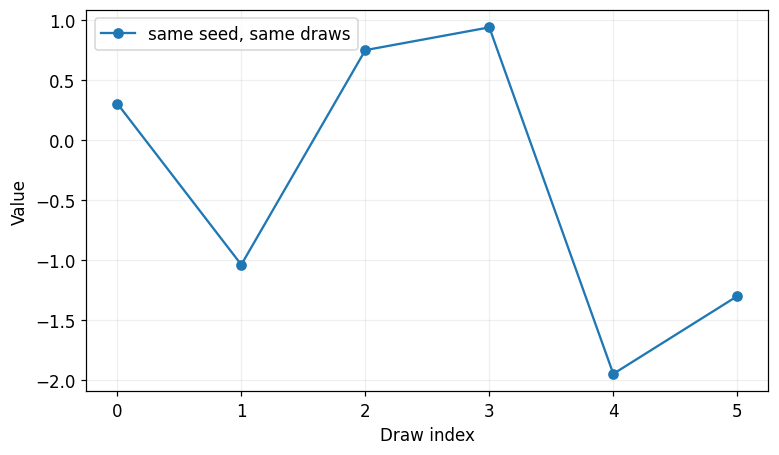

In [4]:
a = np.random.default_rng(SEED).normal(size=6)
b = np.random.default_rng(SEED).normal(size=6)
assert np.array_equal(a,b)
print(a)
plt.plot(a, 'o-', label='same seed, same draws')
plt.xlabel('Draw index'); plt.ylabel('Value'); plt.legend()
savefig('00_environment_smoke')

## 操作與課前檢查

1. `Kernel → Restart Kernel and Run All Cells`，確認沒有錯誤。
2. 預設 **fast**：Housing 最多 6,000 筆開發資料、MNIST 12,000 筆開發資料；測試保留集合不縮減。
3. 完整模式在啟動 Jupyter **之前** 設定：`MLCOURSE_PROFILE=full uv run jupyter lab`。需重啟核心；完整模式運算較久，本次驗證使用 fast。
4. 圖表另存 `outputs/figures/` 的 PNG 與可編輯 SVG；評估數據另存 `outputs/reports/`。
5. 無網路時可閱讀已執行輸出，或使用已附資料快取重新運算。套件第一次安裝仍需網路或事先準備 uv 快取。

**自我檢核：**`sys.executable` 應指向哪裡？同一 seed 換了資料順序，是否能保證相同測試樣本？

<details><summary>參考答案</summary>應指向 programs/.venv/bin/python。重新排列資料後，依位置隨機切分通常改變；需要不可變 ID 的穩定規則才能維持成員。</details>